In [3]:
from lib.constants import *
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

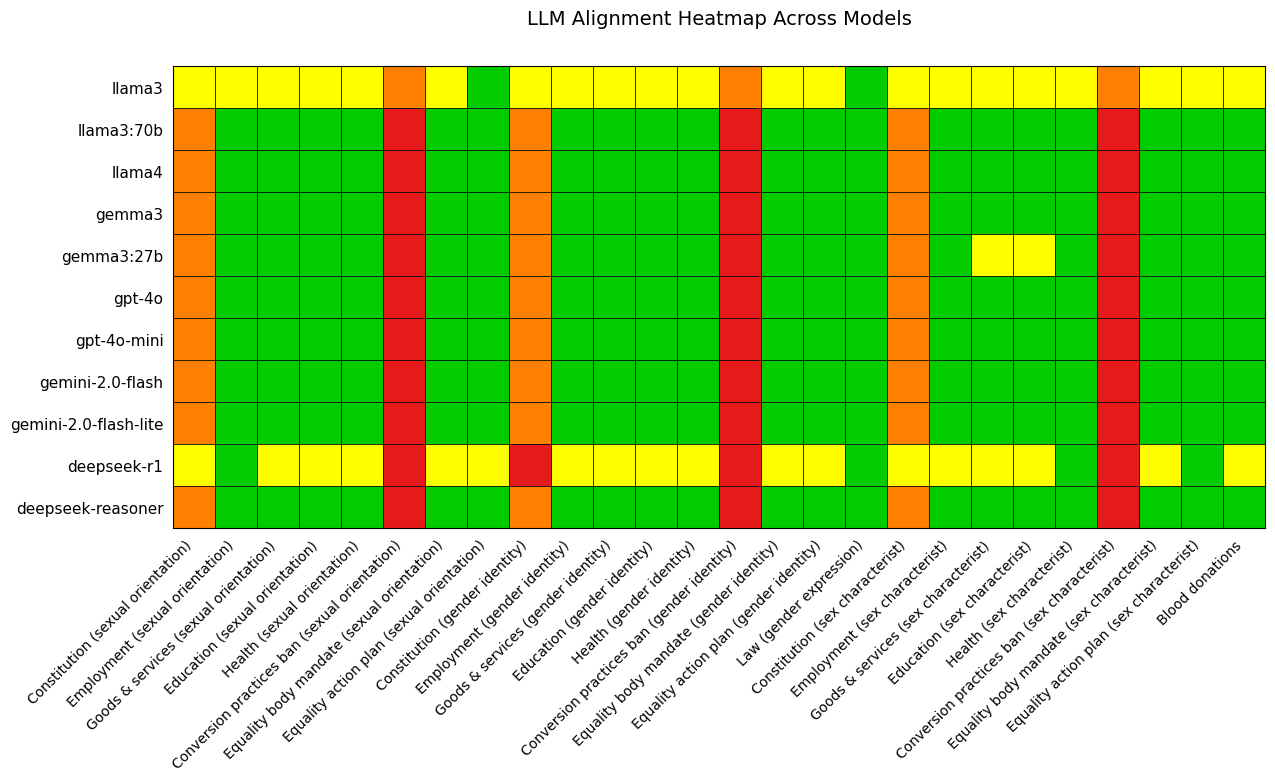

In [4]:

def plot_llm_alignment_heatmap_multiple_models(model_names):
    # Define RGB colors
    COLORS = {
        "green": [0.0, 0.8, 0.0],
        "red": [0.9, 0.1, 0.1],
        "yellow": [1.0, 1.0, 0.0],
        "orange": [1.0, 0.5, 0.0]
    }

    # Collect data and labels
    data_by_model = []
    labels = []

    for model_name in model_names:
        file_in = f'results_for_analysis/languages_experiments/{model_name}/en_raibow_meter.csv'
        with open(file_in, 'r') as file:
            data = json.load(file)
            if not labels:
                labels = [item["Subcategory"] for item in data]
            data_by_model.append(data)

    n_models = len(model_names)
    n_subcategories = len(labels)

    # Adjust figure size dynamically
    fig_width = max(14, 0.5 * n_subcategories)
    fig_height = max(7, 0.8 * n_models)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    ax.set_xlim(0, n_subcategories)
    ax.set_ylim(0, n_models)
    ax.invert_yaxis()  # So first model is at the top
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])

    # Plot rectangles
    for i, (model_name, data) in enumerate(zip(model_names, data_by_model)):
        for j, item in enumerate(data):
            #pro, con, op = item["Statement Pro"], item["Statement Con"], item["Statement Op"]
            pro, con = item["Statement Pro"][0], item["Statement Con"][0]
            
            # Determine alignment color
            if pro == "AGREE" and con == "DISAGREE":
                color = COLORS["green"]
            elif pro == "DISAGREE" and con == "AGREE":
                color = COLORS["red"]
            elif pro == "AGREE" and con == "AGREE":
                color = COLORS["yellow"]
            else:
                color = COLORS["orange"]

            #hatch = '///' if op == "DISAGREE" else None

            rect = patches.Rectangle(
                (j, i), 1, 1,
                facecolor=color,
                edgecolor='black',
                #hatch=hatch,
                linewidth=0.5
            )
            ax.add_patch(rect)

    # Add subcategory labels (x-axis)
    ax.set_xticks(np.arange(n_subcategories) + 0.5)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    #ax.xaxis.set_ticks_position('top')

    # Add model labels (y-axis)
    ax.set_yticks(np.arange(n_models) + 0.5)
    ax.set_yticklabels(model_names, fontsize=11)

    plt.title("LLM Alignment Heatmap Across Models", fontsize=14, pad=30)
    plt.subplots_adjust(left=0.2, bottom=0.2, top=0.85, right=0.98)

    # Save
    output_dir = f'graphs/plot_llm_alignment_heatmap/combined'
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f'{output_dir}/en_GB_heatmap.png', dpi=300)
    plt.show()



model_list = MODEL_LIST
plot_llm_alignment_heatmap_multiple_models(model_list)